In [1]:
import pandas as pd

df = pd.read_csv('archive/merged_output_ready.csv')
print(df)

                timestamp  ADALAR_BOSTANCI  ADALAR_BURGAZADA  ADALAR_BUYUKADA  \
0     2023-01-01 00:00:00         0.000000          0.000000         0.000000   
1     2023-01-01 01:00:00         0.000000          0.000000         0.000000   
2     2023-01-01 02:00:00         0.000000          0.000000         0.000000   
3     2023-01-01 03:00:00         0.000000          0.000000         0.000000   
4     2023-01-01 04:00:00         0.000000          0.000000         0.000000   
...                   ...              ...               ...              ...   
8734  2023-12-31 19:00:00         0.090103          0.032389         0.064713   
8735  2023-12-31 20:00:00         0.036928          0.000000         0.038665   
8736  2023-12-31 21:00:00         0.028065          0.020243         0.031339   
8737  2023-12-31 22:00:00         0.026588          0.000000         0.001221   
8738  2023-12-31 23:00:00         0.000492          0.000000         0.000000   

      ADALAR_HEYBELIADA  AD

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    classification_report,
    confusion_matrix
)



In [22]:
pip install shap


  Using cached numpy-2.3.5-cp311-cp311-win_amd64.whl.metadata (60 kB)
   ---------------------------------------- 0.0/548.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/548.0 kB ? eta -:--:--
   ------------------- -------------------- 262.1/548.0 kB ? eta -:--:--
   ------------------------------------ - 524.3/548.0 kB 882.6 kB/s eta 0:00:01
   ---------------------------------------- 548.0/548.0 kB 831.0 kB/s  0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.7 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.7 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.7 MB ? eta -:--:--
   -

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.17.1 requires numpy<2.0.0,>=1.23.5; python_version <= "3.11", but you have numpy 2.3.5 which is incompatible.

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\Mutlu\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import shap
print("SHAP version:", shap.__version__)


SHAP version: 0.50.0


C:\Users\Mutlu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
!pip install xgboost



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\Mutlu\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [12]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


In [13]:

df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

print(" Veri aralığı:")
print(df["timestamp"].min(), "→", df["timestamp"].max())
print(" Satır sayısı:", len(df))


 Veri aralığı:
2023-01-01 00:00:00 → 2023-12-31 23:00:00
 Satır sayısı: 8739


In [14]:

TARGET_ROUTE = "YENIKAPI - HAVALIMANI_YENIKAPI"
print("Pilot hat:", TARGET_ROUTE)

route_df = df[[
    "timestamp",
    TARGET_ROUTE,
    "hour",
    "day_of_week",
    "month"
]].copy()

route_df.rename(columns={TARGET_ROUTE: "density"}, inplace=True)

display(route_df.head())


Pilot hat: YENIKAPI - HAVALIMANI_YENIKAPI


,timestamp,density,hour,day_of_week,month
0,2023-01-01 00:00:00,0.171894,0,6,1
1,2023-01-01 01:00:00,0.236534,1,6,1
2,2023-01-01 02:00:00,0.162742,2,6,1
3,2023-01-01 03:00:00,0.108590,3,6,1
4,2023-01-01 04:00:00,0.051578,4,6,1


In [15]:
# 1 SAAT SONRASINI TAHMİN ET
route_df["density_t_plus_1h"] = route_df["density"].shift(-1)

print(" NaN sayısı:", route_df["density_t_plus_1h"].isna().sum())


 NaN sayısı: 1


In [16]:

feature_cols = ["hour", "day_of_week", "month", "density"]
target_col = "density_t_plus_1h"

model_df = route_df[feature_cols + [target_col]].dropna()

X = model_df[feature_cols]
y = model_df[target_col]

split_index = int(len(model_df) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print("🟢 Train:", X_train.shape)
print("🔵 Test :", X_test.shape)


🟢 Train: (6990, 4)
🔵 Test : (1748, 4)


In [17]:

xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"📉 MAE  : {mae:.4f}")
print(f"📊 RMSE : {rmse:.4f}")


📉 MAE  : 0.0154
📊 RMSE : 0.0271


In [18]:

def best_departure_time(current_row, model, max_wait=3):

    results = []
    base_density = current_row["density"]

    for h in range(max_wait + 1):
        future_hour = (current_row["hour"] + h) % 24

        X_future = [[
            future_hour,
            current_row["day_of_week"],
            current_row["month"],
            base_density
        ]]

        pred_density = model.predict(X_future)[0]

        results.append({
            "wait_hours": h,
            "predicted_density": round(pred_density, 4)
        })

    return pd.DataFrame(results)

sample_row = route_df.iloc[1000]
decision_df = best_departure_time(sample_row, xgb)
decision_df


,wait_hours,predicted_density
0,0,0.4243
1,1,0.3191
2,2,0.3287
3,3,0.3484


In [19]:

def decision_text(decision_df):

    best_row = decision_df.loc[
        decision_df["predicted_density"].idxmin()
    ]

    wait = int(best_row["wait_hours"])
    best_density = best_row["predicted_density"]
    now_density = decision_df.loc[0, "predicted_density"]

    improvement = (now_density - best_density) / now_density * 100

    if wait == 0:
        return "🚦 Şu anda çıkmak en uygun zaman."

    return (
        f" {wait} saat sonra çıkarsanız "
        f"yoğunluk %{improvement:.1f} azalıyor."
    )

print(decision_text(decision_df))


 1 saat sonra çıkarsanız yoğunluk %24.8 azalıyor.


In [20]:

routes = [
    "YENIKAPI - HAVALIMANI_YENIKAPI",
    "YENIKAPI - HAVALIMANI_ZEYTINBURNU",
    "YENIKAPI - HAVALIMANI_YENIBOSNA"
]

def compare_routes(df, routes, model, row_index=1000):

    results = []

    for route in routes:
        temp_df = df[[
            "timestamp", route, "hour", "day_of_week", "month"
        ]].copy()

        temp_df.rename(columns={route: "density"}, inplace=True)
        current_row = temp_df.iloc[row_index]

        X = [[
            current_row["hour"],
            current_row["day_of_week"],
            current_row["month"],
            current_row["density"]
        ]]

        pred_density = model.predict(X)[0]

        results.append({
            "route": route,
            "predicted_density": round(pred_density, 4)
        })

    return pd.DataFrame(results).sort_values("predicted_density")

compare_df = compare_routes(df, routes, xgb)
compare_df


,route,predicted_density
2,YENIKAPI - HAVALIMANI_YENIBOSNA,0.1438
1,YENIKAPI - HAVALIMANI_ZEYTINBURNU,0.3086
0,YENIKAPI - HAVALIMANI_YENIKAPI,0.4243


In [21]:

def density_to_class(d):
    if d < 0.33:
        return "Rahat"
    elif d < 0.66:
        return "Orta"
    else:
        return "Yogun"

y_pred_cls = [density_to_class(v) for v in y_pred]
y_true_cls = [density_to_class(v) for v in y_test.values]

print(classification_report(y_true_cls, y_pred_cls, digits=3))


              precision    recall  f1-score   support

        Orta      0.924     0.908     0.916       349
       Rahat      0.989     0.982     0.985      1257
       Yogun      0.885     0.979     0.930       142

    accuracy                          0.967      1748
   macro avg      0.933     0.956     0.944      1748
weighted avg      0.967     0.967     0.967      1748



,feature,importance
3,density,0.517146
0,hour,0.442442
1,day_of_week,0.028634
2,month,0.011777


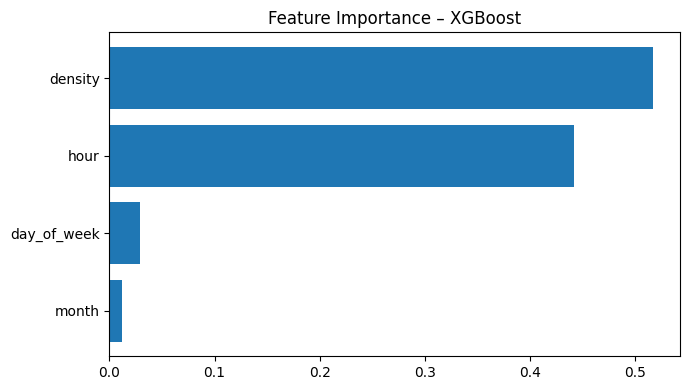

In [25]:
feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb.feature_importances_
}).sort_values("importance", ascending=False)

display(feature_importance)

plt.figure(figsize=(7,4))
plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)
plt.gca().invert_yaxis()
plt.title("Feature Importance – XGBoost")
plt.tight_layout()
plt.show()


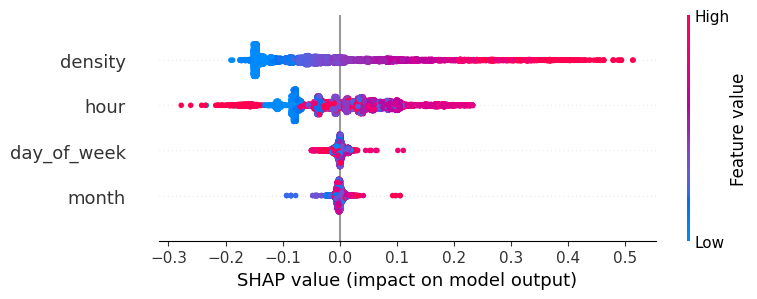

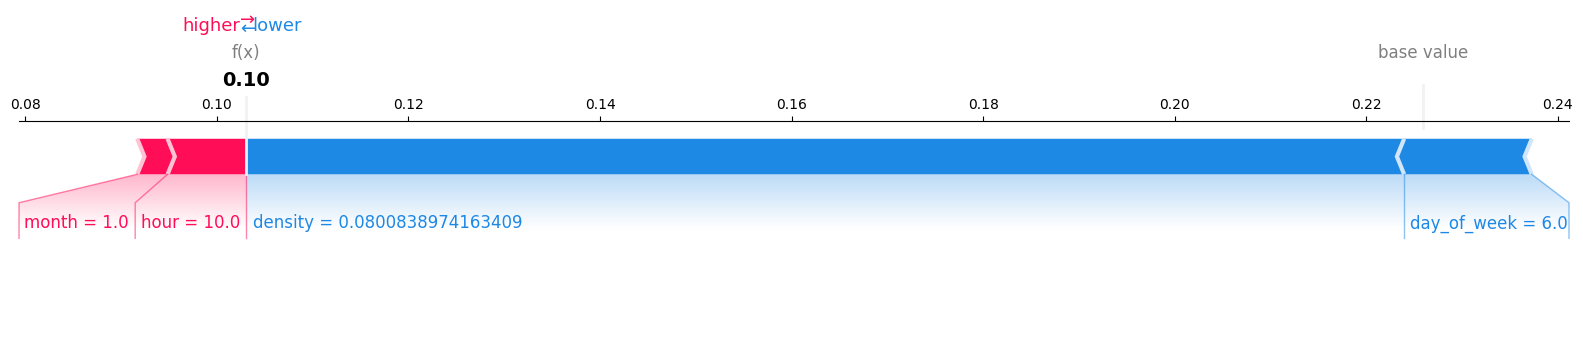

In [22]:

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train)

i = 10
shap.force_plot(
    explainer.expected_value,
    shap_values[i],
    X_train.iloc[i],
    matplotlib=True
)
